# Data Preparation and Analysis

Importing Modules

In [12]:
import pandas as pd
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
from math import cos, degrees

import astropy.constants as const
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error

Unit Conversions

In [13]:
Erg_to_J = 10**-7    # J per erg
cm2_to_m2 = 1/(100**2)  # m2 per cm2
parsec_to_m = 30856775814913673   # m per parsec
SolarRadii_to_m = 6.957*(10**8) # m per solar radii
AU_to_m = 149597870700 # m per AU

Function to generate Pressure-Temperature Profile. Taken from Frontier Development Labs Python code used to create the INARA dataset. The models used in these functions taken from Line et al. (2013)

In [14]:
def xi(gamma, tau):
    return (2.0/3) * (1 + (1/gamma) * (1 + (0.5*gamma*tau-1)*np.exp(-gamma*tau)) +
                        gamma*(1 - 0.5*tau**2) * sp.special.expn(2, gamma*tau)             )    

def PT_line(pressure, params, R_star, T_star, T_int, sma, grav):
    kappa  = 10**(params[0])
    gamma1 = 10**(params[1])
    gamma2 = 10**(params[2])
    alpha, beta = params[3], params[4]

    # Stellar input temperature (at top of atmosphere):
    T_irr = beta * (R_star / (2.0*sma))**0.5 * T_star

    # Gray IR optical depth:
    tau = kappa * (pressure*1e6) / grav # Convert bars to barye (CGS)

    xi1 = xi(gamma1, tau)
    xi2 = xi(gamma2, tau)

    # Temperature profile (Eq. 13 of Line et al. 2013):
    temperature = (0.75 * (T_int**4 * (2.0/3.0 + tau) +
                             T_irr**4 * (1-alpha) * xi1 +
                             T_irr**4 * alpha     * xi2 ) )**0.25

    return temperature

## Ingesting Planetary INARA dataset

In [15]:
df = pd.read_csv('../../Raw Data/Large Validation Data/Dataset 1/psg_models.csv', index_col = 'PlanetIndex', dtype = {'PlanetIndex': str})

## Calculating Stellar and Planetary Signals for each Planet System

The spectral data provided by the INARA dataset is in (erg/s/cm2) and not per micron. The signals are thus likely the intensity of a given bin of wavelengths. These values thus only need to be summed together and not integrated.

In [16]:
for Planet in df.index:
    FileName = Planet + '.csv'
    Spectral_Data = pd.read_csv('../../Raw Data/Large Validation Data/Dataset 1/Spectra/' + FileName, usecols=['wavelength_(um)', 'stellar_signal_(erg/s/cm2)', 'planet_signal_(erg/s/cm2)'])


    # Bolometric signals
    Bolometric_Stellar_Signal = sum(Spectral_Data['stellar_signal_(erg/s/cm2)'].values)
    Bolometric_Stellar_Signal = Bolometric_Stellar_Signal * Erg_to_J * (1 / cm2_to_m2)

    Bolometric_Planet_Signal = sum(Spectral_Data['planet_signal_(erg/s/cm2)'].values)
    Bolometric_Planet_Signal = Bolometric_Planet_Signal * Erg_to_J * (1 / cm2_to_m2)

    df.loc[Planet, 'Bolometric Stellar Signal (W/m2)'] = Bolometric_Stellar_Signal
    df.loc[Planet, 'Bolometric Planet Signal (W/m2)'] = Bolometric_Planet_Signal
  

    SA_Star = 4*(np.pi)*((df.loc[Planet, 'star_radius_in_Solar_radii']*SolarRadii_to_m)**2)     # Surface Area of star
    d = df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs']*parsec_to_m + df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU']*AU_to_m + df.loc[Planet, 'planet_radius_in_km']*1000*2    # distance from telescope to surface of star (assuming earth, planet and star are directly in line with one another)
    df.loc[Planet, 'True Stellar Signal (W/m2)'] = (df.loc[Planet, 'Bolometric Stellar Signal (W/m2)']*(4*np.pi*(d**2)))/SA_Star        # Stellar flux released by the surface of the star

    SA_Planet = 4*(np.pi)*((df.loc[Planet, 'planet_radius_in_km']*1000)**2)                     # Surface Area of planet
    d = df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs']*parsec_to_m      # distance from earth to planet
    df.loc[Planet, 'True Planet Signal (W/m2)'] = (df.loc[Planet, 'Bolometric Planet Signal (W/m2)']*(4*np.pi*(d**2))) / SA_Planet                  # Planetary flux released by the surface of the planet

    # generation of Pressure-Temperature Profiles
    P_prof = np.logspace(np.log10(df.loc[Planet, 'planet_surface_pressure_bars']), np.log10(1e-6), 50) # bar

    density = df.loc[Planet, 'planet_density']
    rplanet     = df.loc[Planet, 'planet_radius_in_km']
    mplanet = density *  (4./3. * np.pi * (rplanet * const.R_earth.cgs.value)**3) / const.M_earth.cgs.value
    surfgrav = const.G.cgs.value * mplanet * const.M_earth.cgs.value /  \
                   (rplanet * const.R_earth.cgs.value)**2
    
    T_prof = PT_line(P_prof, [df.loc[Planet, 'kappa'], df.loc[Planet, 'gamma1'], df.loc[Planet, 'gamma2'], df.loc[Planet, 'alpha'], df.loc[Planet, 'beta']], df.loc[Planet, 'star_radius_in_Solar_radii']* const.R_sun.value, df.loc[Planet, 'star_temperature_in_Kelvin'], 0, df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU']* const.au.value, surfgrav) # K

    df.loc[Planet, 'planet_surface_temperature_Kelvin'] = T_prof[0]
                                                   

# Haqq-Misra 2018 approximation for TOA albedo

## Creation of Dataframe

In [17]:
df_approx = df[['star_temperature_in_Kelvin', 'planet_surface_temperature_Kelvin', 'planets_mean_surface_albedo', 'CO2']]
df_approx


,star_temperature_in_Kelvin,planet_surface_temperature_Kelvin,planets_mean_surface_albedo,CO2
PlanetIndex,,,,
0002085,5797.819484,231.916921,0.490621,0.045443
0002091,5774.429586,192.484480,0.226993,0.284429
0002094,5750.610735,213.534139,0.565502,0.309758
0002101,5752.337743,258.289280,0.483707,0.065438
0000203,5766.313480,326.042465,0.574860,0.105633
...,...,...,...,...
0034914,5771.029259,255.505460,0.647088,0.524416
0034947,5790.587007,321.888777,0.459429,0.027422
0034960,5763.825884,212.540509,0.387861,0.349605


## TOA, LIMIT CYCLES CAN REDUCE THE WIDTH OF THE HABITABLE  ZONE, Jacob Haqq-Misra 2018

In [18]:
Coefficients = [
    -4.41391619954555503025e-01,
    -2.60017516002879089942e-01,
    +1.08110772295329837789e+00,
    -3.93863285843020910493e-02,
    -1.46383456258096611435e+00,
    +9.91383778608142668398e-02,
    -1.45914724229303338632e+00,
    -2.72769392852398387395e-02,
    +3.99933641081463919775e+00,
    +1.07231336256525633388e+00,
    -1.04302520934751417891e-02,
    -6.10296439299006454604e+00,
    +2.69255203910960137434e-03,
    +9.50143253373007257157e-02,
    +7.37864215757422226005e+00,
    +1.28580729156335171748e-01,
    -3.07800300913486257759e-01,
    +2.27715594632176554502e-02,
    +6.11699085276039222769e-01,
    -2.33213409642421742873e+00,
    +2.56011431303802661219e-01,
    +1.05912148222549546972e+01,
    -1.85772688884413561539e-02,
    -7.55796861024326749323e-01,
    -1.16485004141808623501e+01,
    +2.74062491988752192640e+01,
    +5.46044240911252587445e-01,
    -2.05761674358916081928e+02,
    +5.57943359123403426203e-02,
    -2.49880329758542751861e+00,
    +5.14448995054491206247e+02,
    +2.43702089287719950508e-03,
    -1.09384840764980617589e-01,
    +2.92643187434628071486e+00,
    -4.27802454850920923946e+02,
]


df['pH2O (bar)'] = df['planet_surface_pressure_bars']*df['H2O']
df['pCO2 (bar)'] = df['planet_surface_pressure_bars']*df['CO2']
df['pO2 (bar)'] = df['planet_surface_pressure_bars']*df['O2']
df['pN2 (bar)'] = df['planet_surface_pressure_bars']*df['N2']
df['pCH4 (bar)'] = df['planet_surface_pressure_bars']*df['CH4']
df['pN2O (bar)'] = df['planet_surface_pressure_bars']*df['N2O']
df['pCO (bar)'] = df['planet_surface_pressure_bars']*df['CO']
df['pO3 (bar)'] = df['planet_surface_pressure_bars']*df['O3']
df['pSO2 (bar)'] = df['planet_surface_pressure_bars']*df['SO2']
df['pNH3 (bar)'] = df['planet_surface_pressure_bars']*df['NH3']
df['pC2H6 (bar)'] = df['planet_surface_pressure_bars']*df['C2H6']
df['pNO2 (bar)'] = df['planet_surface_pressure_bars']*df['NO2']

df['t'] = np.log10(df['planet_surface_temperature_Kelvin'])
df['Phi'] = np.log10(df['pCO2 (bar)'])
mu = cos(22.5)

c   = Coefficients
t   = df['t']
phi = df['Phi']
asurf = df['planets_mean_surface_albedo'].to_numpy(dtype=float)

df_approx['Albedo (Polynomial, Haqq-Misra 2018) (W/m2)'] = (
    c[0]*mu**3
  + c[1]*mu**2*asurf
  + c[2]*mu**2*t
  + c[3]*mu**2*phi
  + c[4]*mu**2
  + c[5]*mu*asurf**2
  + c[6]*mu*asurf*t
  + c[7]*mu*asurf*phi
  + c[8]*mu*asurf
  + c[9]*mu*t**2
  + c[10]*mu*t*phi
  + c[11]*mu*t
  + c[12]*mu*phi**2
  + c[13]*mu*phi
  + c[14]*mu
  + c[15]*asurf**3
  + c[16]*asurf**2*t
  + c[17]*asurf**2*phi
  + c[18]*asurf**2
  + c[19]*asurf*t**2
  + c[20]*asurf*t*phi
  + c[21]*asurf*t
  + c[22]*asurf*phi**2
  + c[23]*asurf*phi
  + c[24]*asurf
  + c[25]*t**3
  + c[26]*t**2*phi
  + c[27]*t**2
  + c[28]*t*phi**2
  + c[29]*t*phi
  + c[30]*t
  + c[31]*phi**3
  + c[32]*phi**2
  + c[33]*phi
  + c[34]
 )
df


C:\Users\Andrew\AppData\Local\Temp\ipykernel_21208\1769574179.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_approx['Albedo (Polynomial, Haqq-Misra 2018) (W/m2)'] = (


,star_class,star_temperature_in_Kelvin,star_radius_in_Solar_radii,distance_from_Earth_to_the_system_in_parsecs,semimajor_axis_of_the_planet_in_AU,planet_radius_in_km,planet_density,planet_surface_pressure_bars,kappa,gamma1,...,pCH4 (bar),pN2O (bar),pCO (bar),pO3 (bar),pSO2 (bar),pNH3 (bar),pC2H6 (bar),pNO2 (bar),t,Phi
PlanetIndex,,,,,,,,,,,,,,,,,,,,,
0002085,4,5797.819484,1.297609,13.850133,1.321629,6768.195370,5.622851,3.460688,-3.194014,-1.392354,...,0.077316,0.031422,0.078743,0.016660,0.085356,0.002711,0.000297,2.082756e-05,2.365332,-0.803372
0002091,4,5774.429586,0.999780,4.865322,1.532821,4265.460008,4.992702,0.888166,-2.734972,-1.158571,...,0.010837,0.011637,0.003365,0.002851,0.002088,0.000318,0.000008,6.232367e-07,2.284396,-0.597531
0002094,4,5750.610735,1.166627,14.398530,1.083593,7044.836548,5.830127,1.145327,-3.072501,-0.744784,...,0.079734,0.002736,0.011387,0.002915,0.019775,0.004439,0.000747,8.891942e-06,2.329467,-0.450048
0002101,4,5752.337743,1.233482,1.657518,1.344413,7968.789690,6.233754,1.376675,-2.403343,0.845561,...,0.138385,0.008729,0.025859,0.003220,0.022177,0.001082,0.000753,1.195528e-06,2.412106,-1.045342
0000203,4,5766.313480,0.913776,14.970820,1.166581,9645.011173,7.163922,4.201480,-2.072975,0.885673,...,0.205001,0.049663,0.007551,0.010049,0.002653,0.016343,0.000101,1.720876e-05,2.513274,-0.352799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0034914,4,5771.029259,0.963016,3.043933,1.513756,6193.048715,5.379066,2.202056,-2.620964,0.835114,...,0.036834,0.019054,0.024831,0.005777,0.005920,0.001672,0.000103,1.048480e-05,2.407400,0.062504
0034947,4,5790.587007,1.052389,11.902830,0.799804,7387.053343,6.062195,4.034092,-2.111302,0.367558,...,0.142534,0.058861,0.010574,0.011485,0.039643,0.030121,0.000630,6.302623e-05,2.507706,-0.956160
0034960,4,5763.825884,0.908797,2.172735,1.473123,5578.179487,5.248225,2.918169,-2.631614,0.217041,...,0.055271,0.003275,0.014079,0.001918,0.019907,0.003746,0.000123,1.331978e-05,2.327442,0.008689


The two groups are significantly different
p-value: 0.0


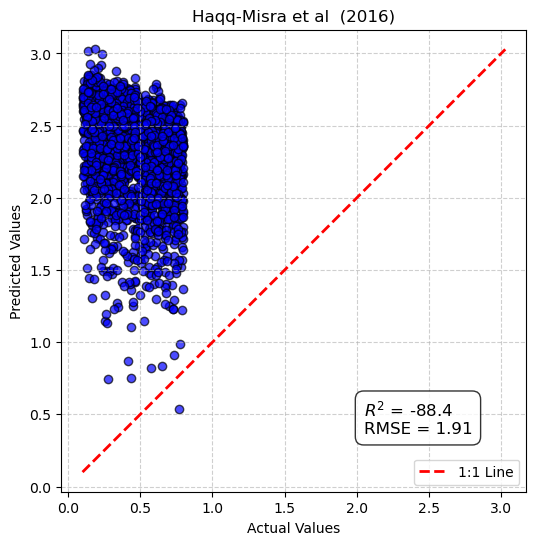

In [24]:
# Testing for Normality
Actual_Stellar_Signals = df_approx['planets_mean_surface_albedo']
Approximation = df_approx['Albedo (Polynomial, Haqq-Misra 2018) (W/m2)']

sA, pA = stats.normaltest(Actual_Stellar_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Stellar_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Stellar_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Stellar_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Stellar_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Stellar_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Stellar_Signals.min(), Approximation.min())
max_val = max(Actual_Stellar_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Haqq-Misra et al  (2016)')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)


plt.show()

In [20]:
# Variables from dataframe
T = df['planet_surface_temperature_Kelvin']
asurf = df['planets_mean_surface_albedo']
p = df['pCO2 (bar)']

# Zenith angle assumption 
Z= 22.5  # degrees
mu = cos(22.5)

# Define polynomials 
def A_toa_low(T, p, mu, asurf):
    return (
        -6.8910e-1
        + 1.0460*asurf
        + 7.8054e-3*T
        - 2.8373e-3*p
        - 2.8899e-1*mu
        - 3.7412e-2*asurf*p
        - 6.3499e-3*mu*p
        + 2.0122e-1*asurf*mu
        - 1.8508e-3*asurf*T
        + 1.3649e-4*mu*T
        + 9.8581e-5*p*T
        + 7.3239e-2*asurf**2
        - 1.6555e-5*T**2
        + 6.5817e-4*p**2
        + 8.1218e-2*mu**2
    )

def A_toa_high(T, p, mu, asurf):
    return (
        1.1082
        + 1.5172*asurf
        - 5.7993e-3*T
        + 1.9705e-2*p
        - 1.8670e-1*mu
        - 3.1355e-2*asurf*p
        + 1.0214e-2*mu*p
        + 2.0986e-1*asurf*mu
        - 3.7098e-3*asurf*T
        + 1.1335e-4*mu*T
        + 5.3714e-5*p*T
        + 7.5887e-2*asurf**2
        - 9.2690e-6*T**2
        - 4.1327e-4*p**2
        + 6.3298e-2*mu**2
    )

# Apply correct fit per temperature
df['A_TOA'] = np.where(
    df['planet_surface_temperature_Kelvin'] < 280,
    A_toa_low(T, p, mu, asurf),
    np.nan
)
df

,star_class,star_temperature_in_Kelvin,star_radius_in_Solar_radii,distance_from_Earth_to_the_system_in_parsecs,semimajor_axis_of_the_planet_in_AU,planet_radius_in_km,planet_density,planet_surface_pressure_bars,kappa,gamma1,...,pN2O (bar),pCO (bar),pO3 (bar),pSO2 (bar),pNH3 (bar),pC2H6 (bar),pNO2 (bar),t,Phi,A_TOA
PlanetIndex,,,,,,,,,,,,,,,,,,,,,
0002085,4,5797.819484,1.297609,13.850133,1.321629,6768.195370,5.622851,3.460688,-3.194014,-1.392354,...,0.031422,0.078743,0.016660,0.085356,0.002711,0.000297,2.082756e-05,2.365332,-0.803372,0.752525
0002091,4,5774.429586,0.999780,4.865322,1.532821,4265.460008,4.992702,0.888166,-2.734972,-1.158571,...,0.011637,0.003365,0.002851,0.002088,0.000318,0.000008,6.232367e-07,2.284396,-0.597531,0.615153
0002094,4,5750.610735,1.166627,14.398530,1.083593,7044.836548,5.830127,1.145327,-3.072501,-0.744784,...,0.002736,0.011387,0.002915,0.019775,0.004439,0.000747,8.891942e-06,2.329467,-0.450048,0.804706
0002101,4,5752.337743,1.233482,1.657518,1.344413,7968.789690,6.233754,1.376675,-2.403343,0.845561,...,0.008729,0.025859,0.003220,0.022177,0.001082,0.000753,1.195528e-06,2.412106,-1.045342,0.713816
0000203,4,5766.313480,0.913776,14.970820,1.166581,9645.011173,7.163922,4.201480,-2.072975,0.885673,...,0.049663,0.007551,0.010049,0.002653,0.016343,0.000101,1.720876e-05,2.513274,-0.352799,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0034914,4,5771.029259,0.963016,3.043933,1.513756,6193.048715,5.379066,2.202056,-2.620964,0.835114,...,0.019054,0.024831,0.005777,0.005920,0.001672,0.000103,1.048480e-05,2.407400,0.062504,0.801269
0034947,4,5790.587007,1.052389,11.902830,0.799804,7387.053343,6.062195,4.034092,-2.111302,0.367558,...,0.058861,0.010574,0.011485,0.039643,0.030121,0.000630,6.302623e-05,2.507706,-0.956160,NaN
0034960,4,5763.825884,0.908797,2.172735,1.473123,5578.179487,5.248225,2.918169,-2.631614,0.217041,...,0.003275,0.014079,0.001918,0.019907,0.003746,0.000123,1.331978e-05,2.327442,0.008689,0.717011


In [21]:
df.dropna(subset=['A_TOA'], inplace=True)

The two groups are significantly different
p-value: 9.704703266123687e-298


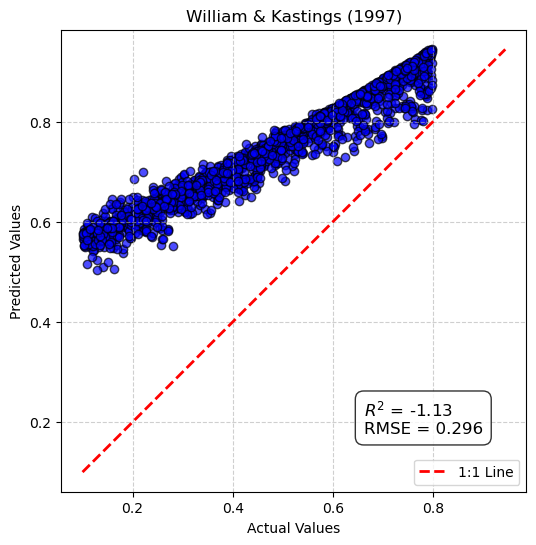

In [23]:
# Testing for Normality
Actual_Stellar_Signals = df['planets_mean_surface_albedo']
Approximation = df['A_TOA']

sA, pA = stats.normaltest(Actual_Stellar_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Stellar_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Stellar_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Stellar_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Stellar_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Stellar_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Stellar_Signals.min(), Approximation.min())
max_val = max(Actual_Stellar_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('William & Kastings (1997)')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)


plt.show()